# Домашнее задание: деревья, случайный лес, бустинг

В этом ноутбуке вы обучите и сравните модели на реальном табличном датасете.

Что нужно сделать:
- подготовить данные и сделать train/test split;
- обучить решающее дерево и проверить качество;
- посмотреть, как качество меняется при разных параметрах дерева;
- обучить Random Forest и градиентный бустинг;
- разобраться в том, как устроены модели и как можно управлять ими

Формат:
- места для вашего кода помечены `# TODO`;
- после каждого задания есть `assert`-проверки;
- если все `assert` проходят - задание выполнено корректно.


## Блок 0. Данные

В этой части вы загрузите датасет `Adult` и подготовите данные для обучения моделей.

В датасете есть числовые и категориальные признаки.  
Все признаки должны быть приведены к числовому виду, чтобы их можно было использовать в моделях.

Мы будем использовать:
- числовые признаки:
  - `age`
  - `education-num`
  - `capital-gain`
  - `capital-loss`
  - `hours-per-week`
- категориальные признаки:
  - `workclass`
  - `education`
  - `marital-status`
  - `occupation`
  - `sex`

Категориальные признаки нужно закодировать с помощью **label encoding**.

Целевая переменная:
- `income` — бинарная (`>50K` / `<=50K`).

На выходе этого блока у вас должны получиться:
- матрица признаков `X`, содержащая только числовые значения;
- целевой вектор `y`, содержащий только 0 и 1.


In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd


In [2]:
# TODO: загрузите датасет Adult как DataFrame
# используйте fetch_openml(..., as_frame=True)
from sklearn.datasets import fetch_openml

adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

X = adult.data
y = adult.target

df = X.copy()
df['income'] = y

In [ ]:
# TODO:
# 1. Посмотрите на структуру данных:
#    – выведите info() и describe() для числовых признаков.
# 2. Посмотрите на распределение целевой переменной:
#    – выведите количество объектов каждого класса;
#    – постройте простой график распределения таргета.
#
# Цель блока — понять размер датасета, типы признаков
# и баланс классов перед обучением моделей.
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


In [3]:
# TODO: выберите нужные признаки и таргет
# удалите строки с пропусками
num_cols = [
    'age',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

cat_cols = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'sex'
]

cols = num_cols + cat_cols
df = df.dropna()
X = df[cols].copy()
y = (df['income'] == '>50K').astype(int)
y.unique()

array([0, 1])

In [4]:
# проверки базовой структуры
assert isinstance(X, pd.DataFrame)
assert isinstance(y, pd.Series)

assert set(num_cols + cat_cols) == set(X.columns)
assert X.shape[0] == y.shape[0]
assert X.isna().sum().sum() == 0
assert set(y.unique()) <= {0, 1}


In [5]:
# TODO:
# 1. Закодируйте категориальные признаки из cat_cols с помощью LabelEncoder
#    (отдельный энкодер для каждого признака).
# 2. Сохраните энкодеры в словарь encoders.
# 3. Приведите закодированные признаки к типу int.
#
# Примечание:
# LabelEncoder не использует таргет и не считает статистики по данным,
# поэтому такое кодирование допустим
from sklearn.preprocessing import LabelEncoder

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    encoders[col] = le.fit(X[col])
    X[col] = le.transform(X[col]).astype(int)

In [ ]:
encoders

{'workclass': LabelEncoder(),
 'education': LabelEncoder(),
 'marital-status': LabelEncoder(),
 'occupation': LabelEncoder(),
 'sex': LabelEncoder()}

In [6]:
# проверки после кодирования
assert X.dtypes.apply(lambda t: t.kind in {'i', 'u', 'f'}).all()
assert X.isna().sum().sum() == 0


In [7]:
# TODO: выполните train / test split
# test_size = 0.3
# используйте фиксированный random_state
# используйте стратификацию по y

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)


In [8]:
# проверки
assert X_train.shape[0] > X_test.shape[0]
assert X_train.shape[1] == X_test.shape[1]

total_size = len(X_train) + len(X_test)
assert abs(len(X_test) / total_size - 0.3) < 1e-3

assert set(y_train.unique()) == set(y_test.unique()) == {0, 1}

assert set(X_train.index).isdisjoint(set(X_test.index))


## Блок 2. Одно решающее дерево

В этом блоке вы обучите **одно решающее дерево** и оцените качество модели.

Используйте:
- `DecisionTreeClassifier`;
- параметры по умолчанию;
- фиксированный `random_state`.

В качестве метрики используйте **accuracy**.

На выходе этого блока у вас должны получиться:
- обученная модель `tree_clf`;
- значение accuracy на train;
- значение accuracy на test.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [ ]:
# TODO: обучите решающее дерево на обучающей выборке

tree_clf = DecisionTreeClassifier()

tree_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# TODO: посчитайте accuracy на train и test

tree_train_acc = accuracy_score(y_train, tree_clf.predict(X_train))
tree_test_acc = accuracy_score(y_test, tree_clf.predict(X_test))
tree_train_acc, tree_test_acc

(0.9680619175485705, 0.8145500110562394)

In [ ]:
# проверки
assert isinstance(tree_train_acc, float)
assert isinstance(tree_test_acc, float)

assert 0 <= tree_train_acc <= 1
assert 0 <= tree_test_acc <= 1

# sanity: дерево обычно лучше работает на train, чем на test
assert tree_train_acc >= tree_test_acc


## Блок 3. Ручной перебор параметров решающего дерева

В этом блоке вы исследуете, как параметры решающего дерева влияют на качество модели.

Вам нужно:
- задать сетку параметров;
- перебрать все комбинации параметров **вручную**;
- для каждой комбинации:
  - обучить модель;
  - посчитать accuracy на train и test;
- сохранить результаты в таблицу;
- выбрать лучшую модель по заданному правилу.

Ограничения:
- не используйте `GridSearchCV`
- используйте только циклы и базовые структуры данных.


In [ ]:
# Стандартная сетка гиперпараметров, которую будем арссматривать:

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 5, 10, 50],
    "min_samples_split": [2, 10, 50],
    "max_features": [None, "sqrt"],
}


In [ ]:
# TODO: выполните полный перебор параметров из param_grid.
# Для каждой комбинации значений:
# - обучите DecisionTreeClassifier (random_state=42);
# - посчитайте accuracy на train и test.
#
# Сохраняйте результаты в список results в виде словарей со следующими ключами:
# - "max_depth"
# - "min_samples_leaf"
# - "min_samples_split"
# - "max_features"
# - "train_accuracy"
# - "test_accuracy"
#
# В results должен быть по одному словарю на каждую комбинацию параметров.

results = []

for max_depth in param_grid["max_depth"]:
    for min_samples_leaf in param_grid["min_samples_leaf"]:
        for min_samples_split in param_grid["min_samples_split"]:
            for max_features in param_grid["max_features"]:
                tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split,
                                              min_samples_leaf=min_samples_leaf, max_features=max_features,
                                              random_state=42)
                tree.fit(X_train, y_train)
                train_accuracy = accuracy_score(y_train, tree.predict(X_train))
                test_accuracy = accuracy_score(y_test, tree.predict(X_test))

                cur_res = {
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "min_samples_split": min_samples_split,
                    "max_features": max_features,
                    "train_accuracy": train_accuracy,
                    "test_accuracy": test_accuracy
                }
                results.append(cur_res)

In [ ]:
# TODO: соберите результаты в DataFrame
grid_cols = ["max_depth","min_samples_leaf","min_samples_split","max_features","train_accuracy","test_accuracy"]
results_df = pd.DataFrame(results)


In [ ]:
# TODO: выберите лучшую модель по следующему правилу:
# 1) максимальный test_accuracy
# 2) при равенстве — минимальная разница между train_accuracy и test_accuracy
results_df['gap'] = abs(results_df['train_accuracy'] - results_df['test_accuracy'])

best_tree = results_df.sort_values(by=['test_accuracy','gap'], ascending=[False, True]).iloc[0]
best_params = best_tree[["max_depth", "min_samples_leaf", "min_samples_split", "max_features"]].to_dict()
best_test_accuracy = best_tree['test_accuracy']
best_params

{'max_depth': nan,
 'min_samples_leaf': 50,
 'min_samples_split': 2,
 'max_features': None}

In [ ]:
# проверки

assert isinstance(results_df, pd.DataFrame)

expected_cols = {
    "max_depth",
    "min_samples_leaf",
    "min_samples_split",
    "max_features",
    "train_accuracy",
    "test_accuracy",
}
assert expected_cols.issubset(results_df.columns)

expected_rows = (
    len(param_grid["max_depth"])
    * len(param_grid["min_samples_leaf"])
    * len(param_grid["min_samples_split"])
    * len(param_grid["max_features"])
)
assert results_df.shape[0] == expected_rows

assert isinstance(best_params, dict)
assert set(best_params.keys()) == {
    "max_depth",
    "min_samples_leaf",
    "min_samples_split",
    "max_features",
}

assert isinstance(best_test_accuracy, float)
assert best_test_accuracy == results_df["test_accuracy"].max()
assert 0 <= best_test_accuracy <= 1


### Визуализация лучшего дерева

В этом задании нужно визуализировать **лучшее решающее дерево**, найденное в предыдущем блоке.

Сначала — ограниченная визуализация прямо в ноутбуке,  
затем — полная визуализация дерева, сохранённая в файл.


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


In [ ]:
# TODO: обучите лучшее дерево с параметрами best_params
# используйте те же train-данные. У вас могут возникнуть проблемы с глубиной дерева, подумайте как их решить

best_tree = DecisionTreeClassifier(max_depth=None, min_samples_split=2,
                                   min_samples_leaf=50, max_features=None)
best_tree.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


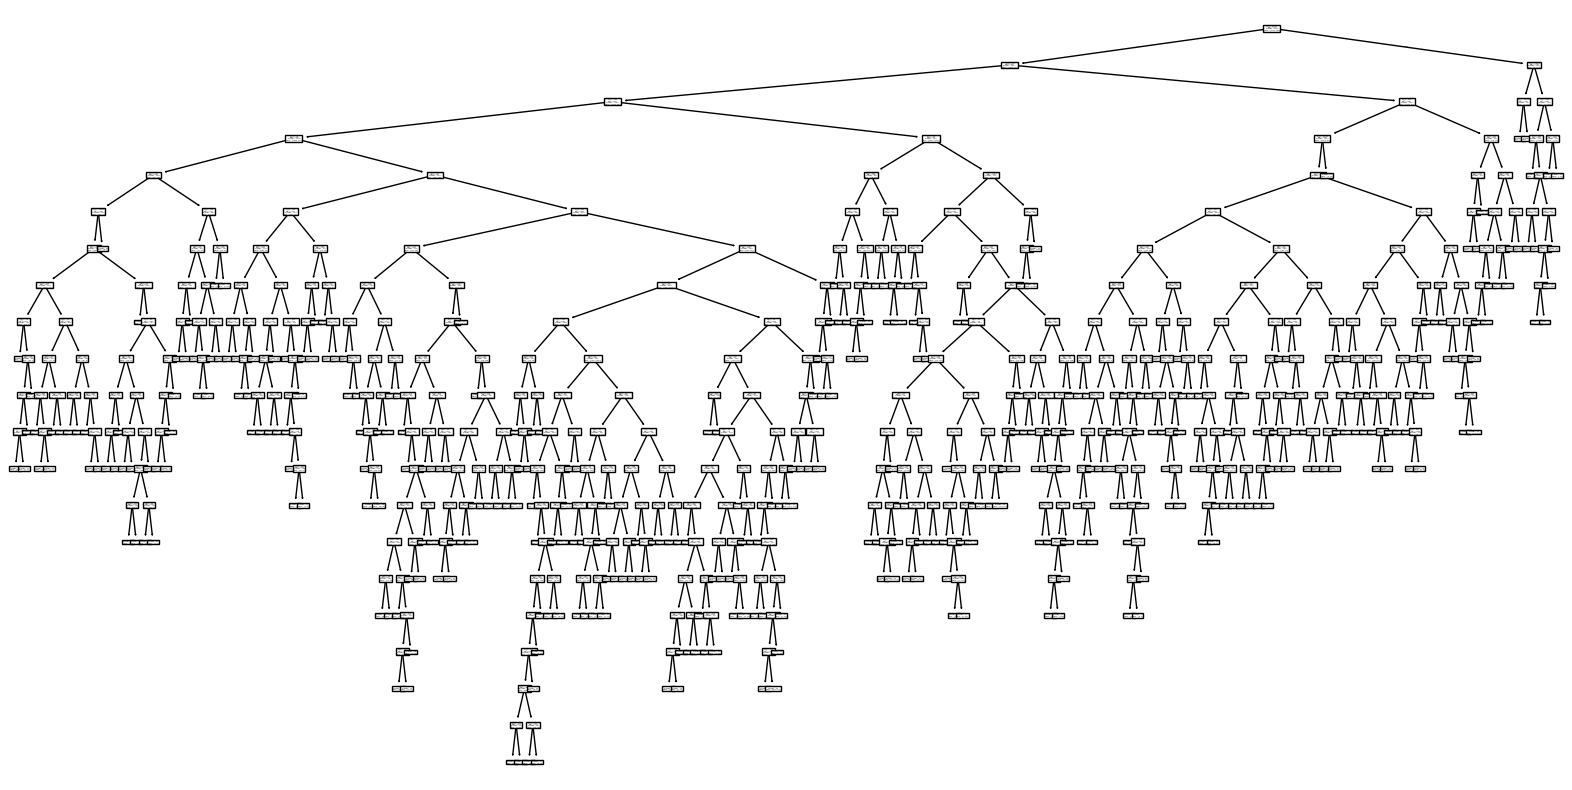

In [ ]:
# TODO: визуализируйте дерево в ноутбуке
# - используйте plot_tree
# - ограничьте глубину визуализации
# - подпишите признаки и классы

plt.figure(figsize=(20, 10))

# TODO
plot_tree(best_tree)
plt.show()


**Вопросы**  
Посмотрите на визуализацию дерева выше.

1. Какое разбиение используется в корне дерева?  
2. Какой признак сильнее всего влияет на предсказание дохода в этом дереве?  
3. Что можно сказать про объекты с большим значением `capital-gain`?

In [ ]:
# проверки
assert best_tree is not None


### Полная визуализация дерева (в файл)

Теперь сохраните **полную визуализацию** этого же дерева в PDF-файл.

Требования:
- не ограничивайте глубину визуализации;
- не отображайте график в ноутбуке;
- сохраните результат в файл `best_tree_full.pdf`.


In [ ]:
# TODO: сохраните полную визуализацию лучшего дерева в PDF-файл

# имя файла
output_path = "best_tree_full.pdf"

plt.figure(figsize=(40, 20))

# TODO
plot_tree(best_tree)
plt.savefig(output_path)
plt.close()


In [ ]:
# проверки
import os

assert os.path.exists(output_path)
assert os.path.getsize(output_path) > 0


## Блок 4. Random Forest

В этом блоке вы исследуете, как параметры случайного леса влияют
на качество модели.

Вам нужно:
- перебрать несколько параметров Random Forest;
- сохранить результаты в таблицу;
- выбрать лучшую модель;
- визуализировать зависимости качества от параметров.


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [10]:
# Возьмём следующую сетку параметров:

param_grid = {
    "n_estimators": [5, 10, 20, 30, 50, 75, 100, 150, 200],
    "max_depth": [3, 5, 7, 10, 15, None],
    "max_features": ["sqrt", None],
}


In [11]:
# TODO: выполните полный перебор параметров вручную (GridSearchCV использовать не нужно).
# Для каждой комбинации параметров:
# - обучите RandomForestClassifier;
# - посчитайте accuracy на train и test;
# - сохраните результаты.
#
# Цель этого блока - руками увидеть влияние параметров модели,
# а не получить «лучший» результат автоматически.
#
# Обратите внимание: ячейка может выполняться 5-7 минут,
# так как обучается большое количество моделей.
rf_results = []

for max_depth in param_grid["max_depth"]:
    for n_estimators in param_grid["n_estimators"]:
        for max_features in param_grid["max_features"]:

            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                max_features=max_features,
                random_state=42
            )

            model.fit(X_train, y_train)

            train_accuracy = accuracy_score(y_train, model.predict(X_train))
            test_accuracy = accuracy_score(y_test, model.predict(X_test))

            rf_results.append({
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "max_features": max_features,
                "train_accuracy": train_accuracy,
                "test_accuracy": test_accuracy
            })

In [12]:
# TODO: соберите результаты в DataFrame
# Колонки:
# - n_estimators
# - max_depth
# - max_features
# - train_accuracy
# - test_accuracy

rf_results_df = pd.DataFrame(rf_results)


In [14]:
# TODO: выберите лучшую модель по test_accuracy.
#
# Требования:
# - best_rf_params должен быть словарём с параметрами лучшей модели;
# - словарь должен содержать ключи:
#   * "n_estimators"
#   * "max_depth"
#   * "max_features"
# - значения в словаре должны подходить для передачи в RandomForestClassifier;
# - best_rf_test_accuracy должно быть числом (float) — максимальным test_accuracy.

b_forest = rf_results_df.sort_values(by='test_accuracy', ascending=False).iloc[0]

best_rf_params = b_forest[["n_estimators","max_depth","max_features"]].to_dict()
best_rf_test_accuracy = b_forest['test_accuracy']
best_rf_test_accuracy

np.float64(0.8626815065968895)

### Влияние параметров Random Forest на качество


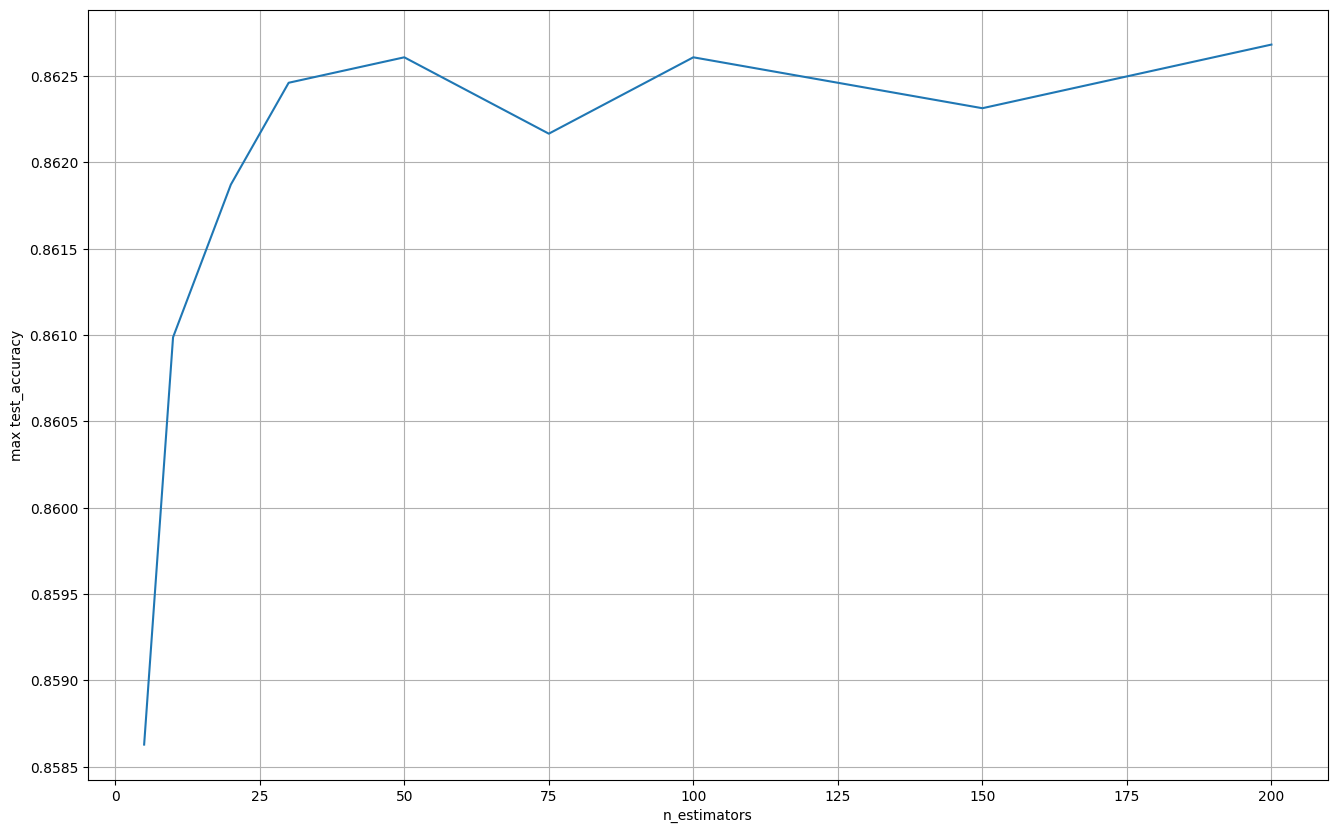

In [15]:
# TODO: постройте график зависимости test_accuracy от n_estimators
# Для каждого значения n_estimators возьмите
# максимальное test_accuracy по всем остальным параметрам

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))
#genre = top3_genres["Genre"].iloc[0]
#genre_yearly = (
#    df_clean[df_clean["Genre"] == genre]
#        .groupby("Year")["Global_Sales"]
#        .mean()
#)
#plt.plot(genre_yearly.index, genre_yearly.values)
#plt.grid(True)
y_acc = rf_results_df.groupby('n_estimators')['test_accuracy'].max()
plt.plot(y_acc.index, y_acc.values)
plt.xlabel("n_estimators")
plt.ylabel("max test_accuracy")
plt.grid(True)
plt.show()

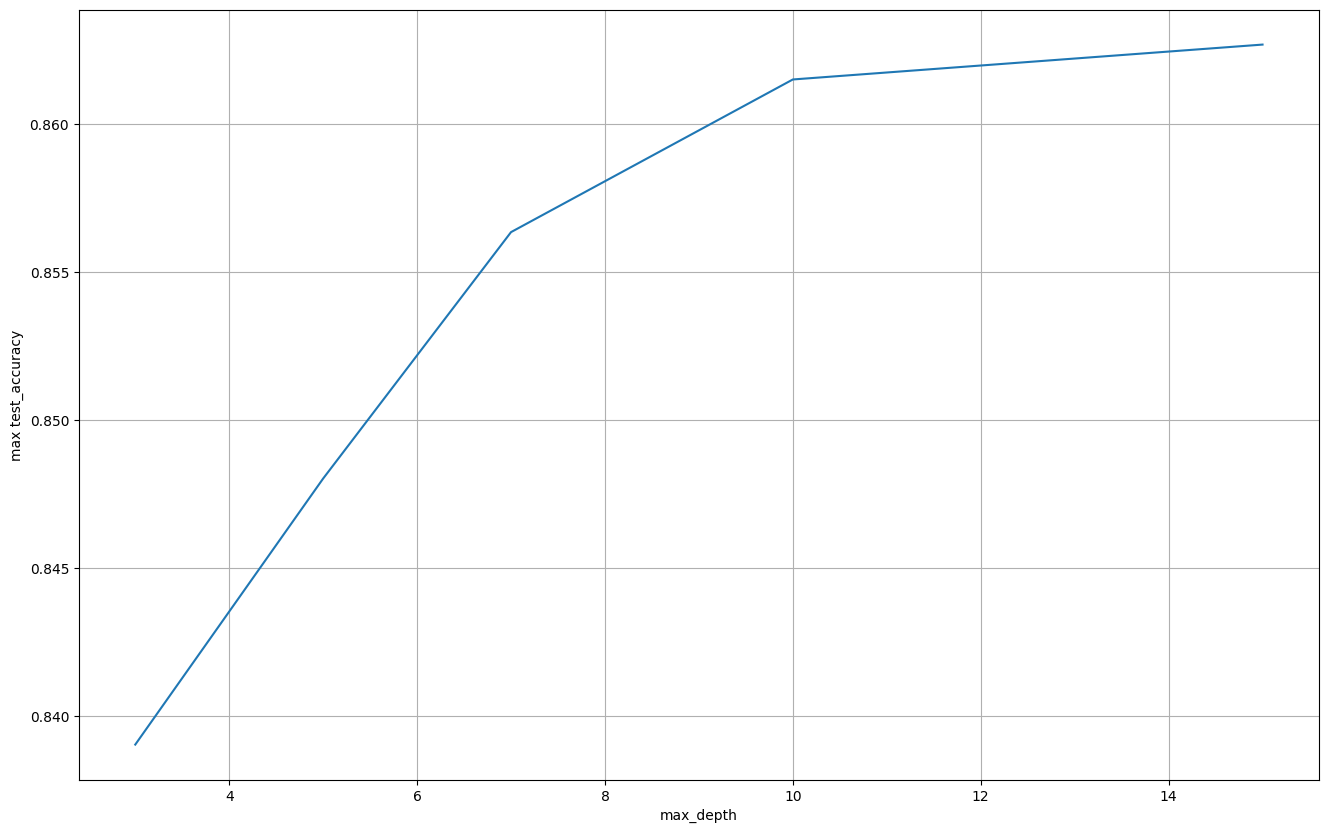

In [16]:
# TODO: постройте график зависимости test_accuracy от max_depth
# Для каждого значения max_depth возьмите
# максимальное test_accuracy по всем остальным параметрам
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

acc_depth = rf_results_df.groupby('max_depth')['test_accuracy'].max()
plt.plot(acc_depth.index, acc_depth.values)
plt.xlabel("max_depth")
plt.ylabel("max test_accuracy")
plt.grid(True)
plt.show()

In [17]:

assert isinstance(rf_results_df, pd.DataFrame)

expected_cols = {
    "n_estimators",
    "max_depth",
    "max_features",
    "train_accuracy",
    "test_accuracy",
}
assert set(rf_results_df.columns) == expected_cols

assert len(rf_results_df) == (
    len(param_grid["n_estimators"])
    * len(param_grid["max_depth"])
    * len(param_grid["max_features"])
)

assert isinstance(best_rf_params, dict)
assert best_rf_test_accuracy == rf_results_df["test_accuracy"].max()


### Наблюдение по результатам

При анализе результатов полезно смотреть не только на лучшую модель,
но и на то, **как качество меняется при изменении параметров**.

В этом блоке мы посмотрели на зависимость качества от числа деревьев
в случайном лесу и увидели характерное поведение:
при увеличении числа деревьев качество на test-выборке
обычно **не ухудшается**, а со временем выходит на плато.

Это одно из ключевых практических свойств случайного леса:
добавление деревьев делает модель более устойчивой,
а не просто «сложнее».

Такие графики помогают понять поведение модели
ещё до выбора конкретных параметров.


----


Ранее мы сравнивали модели по accuracy.  
Для бинарной классификации этого часто недостаточно.

В этом блоке нужно:
- взять **лучший Random Forest**, найденный ранее;
- посчитать основные метрики бинарной классификации на test-выборке;
- собрать их в одном месте.

Метрики:
- accuracy
- precision
- recall
- F1-score

Перед выполнением задания рекомендуется кратко почитать,
что означают precision, recall и F1-score и чем они отличаются друг от друга.


In [24]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
)
best_rf_params["max_depth"] = (int(best_rf_params["max_depth"]))

tr = RandomForestClassifier(**best_rf_params, random_state=42)
tr.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42)

In [25]:
# TODO: обучите лучший Random Forest и посчитайте метрики на test-выборке
# Сохраните результат в словарь metrics_dict
# Ключи:
# - "accuracy"
# - "precision"
# - "recall"
# - "f1"
pred = tr.predict(X_test)
metrics_dict = {'accuracy' : accuracy_score(y_test, pred),
                "precision": precision_score(y_test, pred),
                "recall": recall_score(y_test, pred),
                "f1": f1_score(y_test, pred)
                }
metrics_dict

{'accuracy': 0.8626815065968895,
 'precision': 0.7748966553927095,
 'recall': 0.6199639206253759,
 'f1': 0.6888257892099549}

In [26]:
# проверки
assert isinstance(metrics_dict, dict)
assert set(metrics_dict.keys()) == {"accuracy", "precision", "recall", "f1"}

for value in metrics_dict.values():
    assert isinstance(value, float)
    assert 0 <= value <= 1

# sanity: accuracy должна совпадать с ранее найденной
assert abs(metrics_dict["accuracy"] - best_rf_test_accuracy) < 1e-6


## CatBoost

Теперь посмотрим на градиентный бустинг над деревьями — CatBoost.

По сравнению с Random Forest, CatBoost:
- обучается последовательно;
- поддерживает раннюю остановку (early stopping);
- умеет работать с категориальными признаками напрямую.

Сначала обучим базовую модель, затем посмотрим,
как ведёт себя процесс обучения и как влияют параметры.


In [31]:
# TODO:
# Сформируйте cat_features — список номеров столбцов (int) в X,
# соответствующих категориальным признакам.
#
# Номера столбцов должны соответствовать порядку столбцов в X.
# cat_features должен быть списком чисел, а не названий признаков.
cat_features = [x for x in range(5, 10)]

X.columns[cat_features],cat_cols

(Index(['workclass', 'education', 'marital-status', 'occupation', 'sex'], dtype='object'),
 ['workclass', 'education', 'marital-status', 'occupation', 'sex'],
 [5, 6, 7, 8, 9])

In [32]:
assert isinstance(cat_features, list)
assert all(isinstance(i, int) for i in cat_features)
assert set(X.columns[cat_features]) == set(cat_cols)

In [33]:
# Установим кэтбуст
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [34]:
# Обучим простой кэтбуст. Он умеет умно работать с категориями, поэтому тут нам пригождается список из прошлого задания

from catboost import CatBoostClassifier


catboost_base = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="Logloss",
    random_seed=42,
    early_stopping_rounds=50,
    verbose=False,
)

catboost_base.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
)

base_test_accuracy = accuracy_score(
    y_test,
    catboost_base.predict(X_test)
)

base_test_accuracy


0.8716739146458318

### Что такое Logloss и что мы сейчас наблюдаем

В CatBoost (и в градиентном бустинге в целом) модель обучается,
минимизируя функцию потерь.

Для задачи бинарной классификации одной из стандартных функций потерь
является **логистическая функция потерь (Logloss)**.

Пусть:
- $y \in \{0, 1\}$ — истинный класс объекта,
- $p \in (0, 1)$ — вероятность класса 1, предсказанная моделью.

Тогда logloss для одного объекта равен:

$$
\text{Logloss}(y, p)
= - \left( y \log p + (1 - y) \log (1 - p) \right).
$$

Интуитивно:
- если модель уверенно предсказывает правильный класс — loss маленький;
- если модель уверенно ошибается — loss большой;
- loss штрафует не только ошибки, но и излишнюю уверенность.

Во время обучения CatBoost на каждой итерации:
- обновляет модель;
- пересчитывает logloss на обучающей и тестовой выборках;
- останавливается, когда качество на тесте перестаёт улучшаться
  (early stopping).

Ниже вы увидите, как logloss меняется по итерациям обучения
для разных значений learning rate.


In [ ]:
# TODO:
# Используя обученную модель catboost_base:
#
# 1. Сохраните номер лучшей итерации в переменную best_iter (int)
# 2. Получите словарь с историей обучения и сохраните его в evals_result (dict)
# 3. Из evals_result извлеките:
#    - список значений Logloss на обучающей выборке и сохраните в train_loss (list)
#    - список значений Logloss на test-выборке и сохраните в test_loss (list).
#
# Подсказка:
# все необходимые методы есть у объекта CatBoostClassifier.
# Обратитесь к документации CatBoost, чтобы найти нужные вызовы.

In [ ]:
assert isinstance(best_iter, int)
assert best_iter > 0

assert isinstance(evals_result, dict)
assert "learn" in evals_result
assert "validation" in evals_result

assert isinstance(train_loss, list)
assert isinstance(test_loss, list)
assert len(train_loss) > 0
assert len(test_loss) > 0

assert len(train_loss) == len(test_loss)

assert best_iter < len(train_loss)


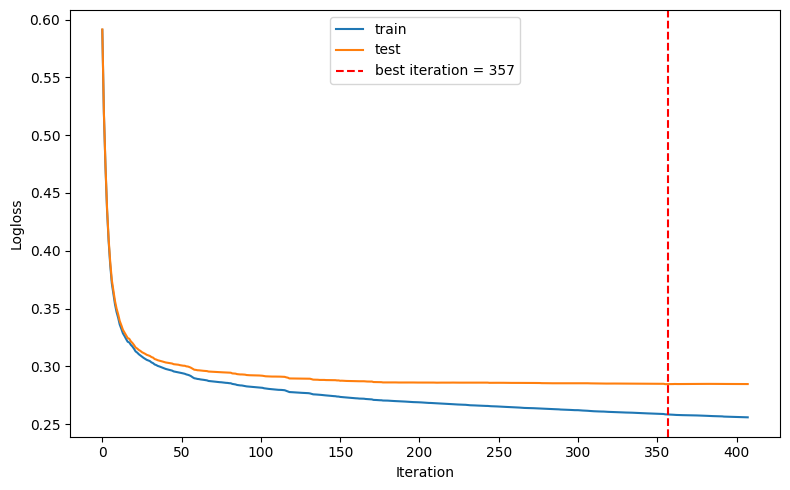

In [ ]:
# Визуализируем что у нас получилось:

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="train")
plt.plot(test_loss, label="test")

plt.axvline(
    best_iter,
    color="red",
    linestyle="--",
    label=f"best iteration = {best_iter}",
)

plt.xlabel("Iteration")
plt.ylabel("Logloss")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# TODO:
# Исследуйте влияние learning_rate в CatBoost.
#
# Необходимо:
# 1. Для каждого значения learning_rate обучить модель CatBoostClassifier
#    с фиксированными параметрами и early stopping.
# 2. Для каждой модели сохранить:
#    - значение learning_rate;
#    - номер лучшей итерации (best_iteration);
#    - accuracy на test-выборке.
# 3. Сохранить результаты в список cb_results в виде словарей.
# 4. Преобразовать cb_results в DataFrame cb_results_df и вывести его.
#
# Требования:
# - cb_results должен быть списком словарей;
# - каждый словарь должен содержать ключи:
#   "learning_rate", "best_iteration", "test_accuracy";
# - cb_results_df должен быть pandas DataFrame.
#
# Подсказка:
# не используйте автоматический перебор параметров.
# Работайте с API CatBoost напрямую.

learning_rates = [0.03, 0.1, 0.3]
cb_results = []

# TODO

In [ ]:
assert isinstance(cb_results, list)
assert len(cb_results) == len(learning_rates)

for row in cb_results:
    assert isinstance(row, dict)
    assert set(row.keys()) == {
        "learning_rate",
        "best_iteration",
        "test_accuracy",
    }

    assert isinstance(row["learning_rate"], float)
    assert isinstance(row["best_iteration"], int)
    assert isinstance(row["test_accuracy"], float)

    assert row["best_iteration"] > 0
    assert 0 <= row["test_accuracy"] <= 1

assert isinstance(cb_results_df, pd.DataFrame)
assert cb_results_df.shape[0] == len(learning_rates)

assert set(cb_results_df.columns) == {
    "learning_rate",
    "best_iteration",
    "test_accuracy",
}


In [ ]:
# TODO: Сравните полученное качество для бустинга (лучший из наборов гиперпараметров) и для Random Forest.
# Что можете сказать про качество? Как его можно было бы улучшить?

В этом эксперименте градиентный бустинг показал качество немного выше,
чем Random Forest на валидационной выборке.
При этом мы использовали довольно грубую настройку модели.

На практике качество CatBoost можно дополнительно улучшить:
более плотным подбором гиперпараметров,
работой с признаками и использованием дополнительных настроек бустинга.
В большинстве табличных задач при аккуратной настройке
градиентный бустинг в итоге оказывается сильнее случайного леса.


### Что ещё можно делать в градиентном бустинге

Градиентный бустинг — это большой класс моделей с огромным количеством настроек.

Даже в рамках CatBoost есть много дополнительных возможностей:
- разные функции потерь и метрики;
- более тонкая настройка регуляризации;
- работа с несбалансированными классами;
- интерпретация модели и анализ важности признаков;
- ускорение обучения и работа с большими данными.

Мы не будем разбирать всё это в этом ноутбуке.
Наша цель была показать базовую механику и основные идеи.
Если хочется углубиться, хорошей отправной точкой будет официальная документация CatBoost.


# Итоги

В этом ноутбуке вы прошли путь от одного решающего дерева
до ансамблевых моделей — Random Forest и градиентного бустинга.

Вы:
- обучили деревья и посмотрели, как они принимают решения;
- исследовали влияние параметров в Random Forest;
- увидели, чем градиентный бустинг отличается от случайного леса;
- познакомились с early stopping и визуализацией процесса обучения.

Теперь у вас есть понимание того, как устроены эти алгоритмы
и какие у них есть точки управления.
Дальше можно либо углубляться в теорию и параметры,
либо применять эти модели на более сложных задачах.
